# ChatBI项目实战

传统BI工具通常分为数据接入层、分析工具层和基于该工具平台的各种行业应用层面，大模型可以在这些环节发挥作用。

- 在数据处理层面，大模型可以帮助传统的ETL(Extraction提取，Transform转换，Loading加载)过程简化难度，提高实时交互效率。
- 在数据分析层面，大模型可以替代拖拽交互方式，让业务用户用更简单、更高效的方式以自然语言形式与底层数据交互，构建需要的报表和看板。
- 在行业应用层面，大模型可以真正发挥对行业知识的理解能力，与具体数据结合，形成具针对客户、特定项目、指标体系的输出，再加上数据准备，可能直接输出标准化的项目成果。

在LLM赋能BI的过程中，Text2SQL(或者称为NL2SQL)将自然语言表述的查询语句转化为SQL语句，是**构建智能BI不可缺少的步骤**。通过本项目，大家可以了解到目前业内主流的基于大模型实现全流程自动化报表生成的技术方案。

首先安装下环境：
```
pip install -r requirements.txt
```



## 基于Prompt模板的方法

让大模型帮助我们将查询要求转化成可执行的SQL语句，这个过程要注意了，大模型生成的SQL语句不一定是可以成功执行的，，所以为了提升生成结果的准确率，我们就要想办法把有用的信息提供给大模型（通过Prompt）。哪些信息是有用的呢？可以想想如果让你去写一个sql语句，你需要哪些信息呢？
- 数据库中的相关表结构：每张表存了哪些字段，每个字段代表什么意思......
- 有些复杂的查询逻辑人都不一定写得对，怎么办？参考别人写好的sql命令。

所以Text2SQL的Prompt基本上就是几个部分组成：

- 指令（Instruction）：比如，“你是一个SQL生成专家。请参考如下的表格结构，直接输出SQL语句，不要多余的解释。”
- 数据结构（Table Schema）：类似于语言翻译中的“词汇表”。即需要使用的数据库表结构，由于大模型无法直接访问数据库，需要把数据的结构组装进入Prompt，通常包括表名、列名、列的类型、列的含义、主外键信息。
- 用户问题（Questions）：自然语言表达的问题，比如，“统计上个月的平均订单额”。
- 参考样例（Few-shot）：这是一个可选项，当然也是提示工程的常见技巧。即指导大模型生成本次SQL的参考样例。
- 其他提示（Tips）：其他认为有必要的指示。比如要求生成的SQL中不允许出现的表达式，或者要求列名必须用“table.column"的形式等。

根据上面的这个教程，我们可以设计出prompt的模板样式：

```text
System

/*系统指令*/
Given the following SQL tables, your job is to write queries given a user’s request.

/*数据库内表结构*/
CREATE TABLE Orders (
  OrderID int,
  CustomerID int,
  OrderDate datetime,
  OrderTime varchar(8),
  PRIMARY KEY (OrderID)
);

...此处省略其他表...

/*问题*/
Write a SQL query which computes the average total order value for all orders on 2023-04-01.
```

现在我们回头来看单纯靠prompt来做Text2SQL，只能偶尔手动去跑一跑单例，因为prompt中间的表结构、示例这两大类信息是要你手动贴进去的，暂时还没办法做到自动填充，那么哟没有办法做到自动填充呢？

## 基于SQLDatabaseChain生成SQL

LangChain提供基于LLM的SQLDatabaseChain，可以利用LLM的能力将自然语言表述的query转化为SQL，连接DB进行查询，并利用LLM组装润色结果，返回最终answer。

### 准备Database数据

这里我们需要找一个数据库来实操下，我们选择[Chinook Database](https://github.com/lerocha/chinook-database)，这是个开源的数据库，我们按照官方的教程下载安装就能在本地就行访问了:
1. 将[这个文件](https://github.com/lerocha/chinook-database/blob/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql)下载下来放到指定目录 
2. 在命令行运行命令：sqlite3 Chinook.db
3. 继续输入：.read Chinook_Sqlite.sql，就能在当前目录下看到生成了新的文件 Chinook.db
4. 测试这个db：SELECT * FROM Artist LIMIT 10

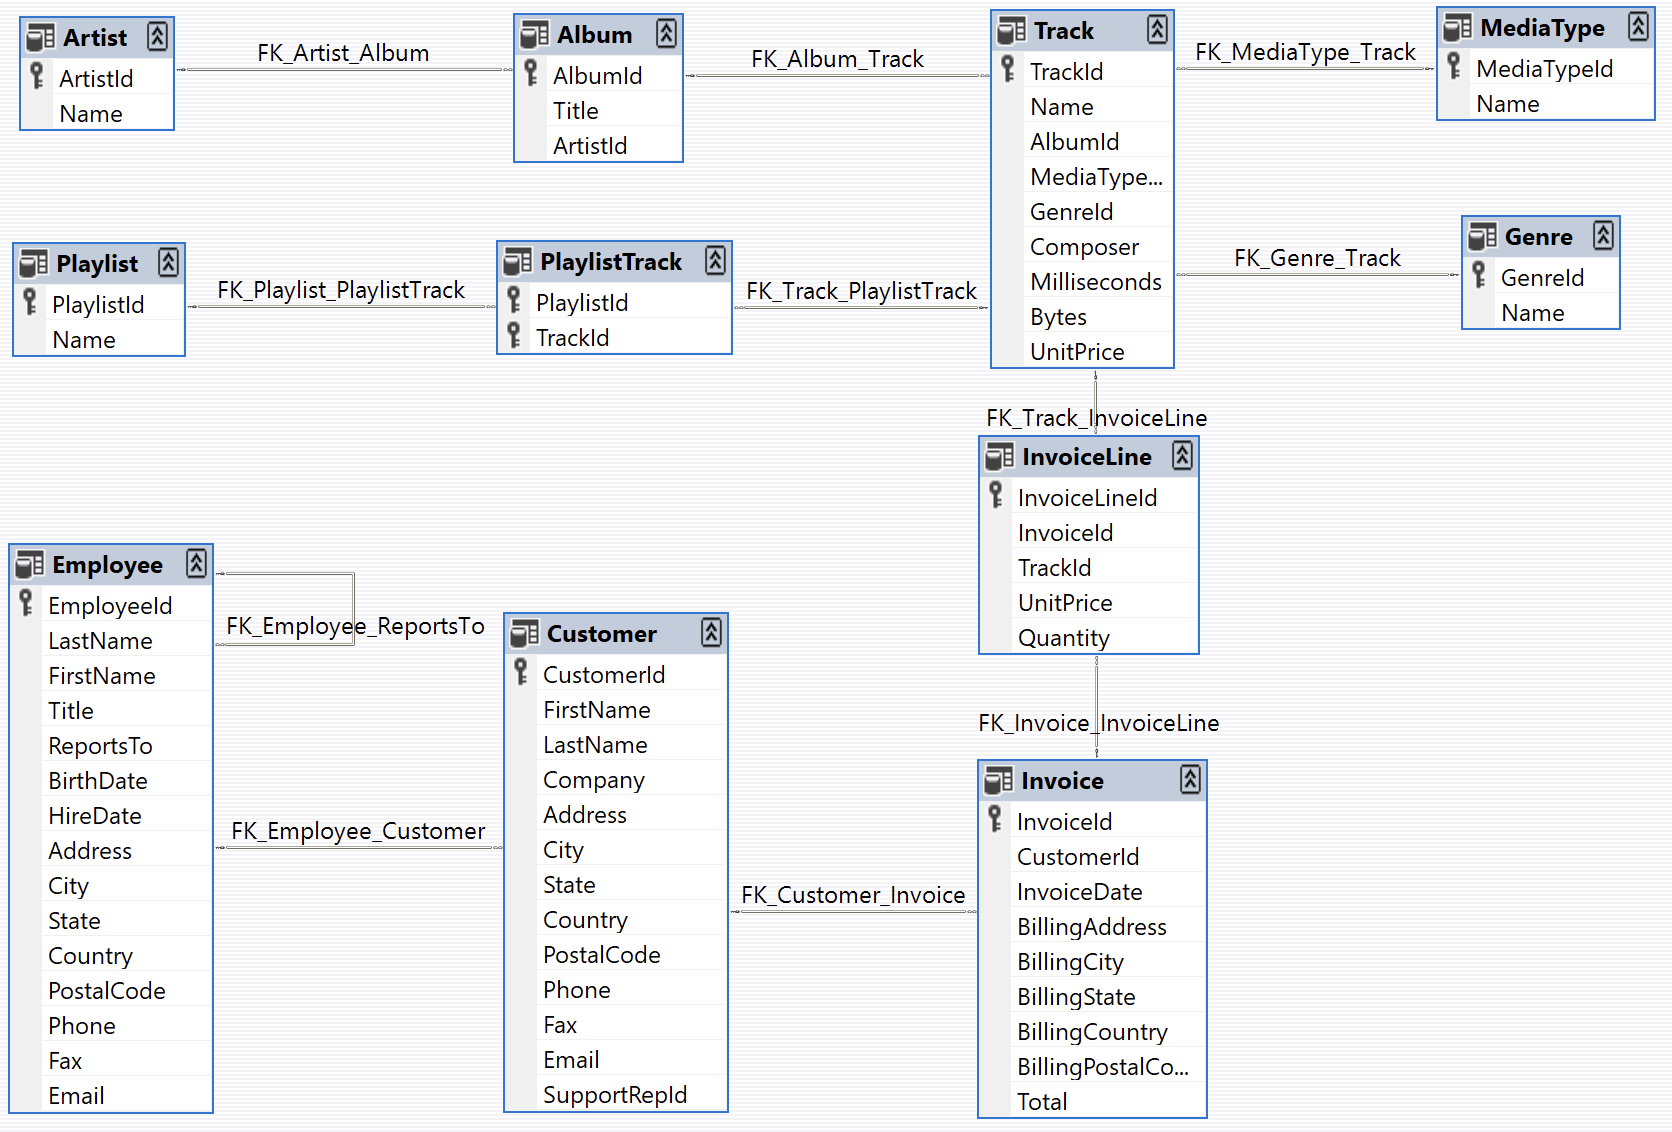

现在Chinhook.db已经在我们的目录中，可以使用SQLAlchemy驱动的SQLDatabase类与它进行接口对接：

In [ ]:
#人写SQL
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")
print(db.dialect)
print(db.get_usable_table_names())      # 查询所有的表
db.run("SELECT * FROM Artist LIMIT 10;")

sqlite
['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains'), (6, 'Antônio Carlos Jobim'), (7, 'Apocalyptica'), (8, 'Audioslave'), (9, 'BackBeat'), (10, 'Billy Cobham')]"

### 调用SQLDatabaseChain
要让大模型写SQL
下面我们就能通过Langchain的接口调用实现Sql生成：

In [4]:
from langchain_openai import OpenAI
from langchain_community.utilities import SQLDatabase
from langchain_experimental.sql import SQLDatabaseChain

In [2]:
import os 
os.environ["OPENAI_API_KEY"] = "your-openai-api-key-here"

In [6]:
db = SQLDatabase.from_uri("sqlite:///Chinook.db")
llm = OpenAI(temperature=0, verbose=True)
db_chain = SQLDatabaseChain.from_llm(llm, db, verbose=True)
db_chain.run("总共有多少员工?")

/var/folders/3k/khd9f1vs1mj6vmthvp_441mc0000gn/T/ipykernel_10959/2169321276.py:4: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  db_chain.run("总共有多少员工?")




> Entering new SQLDatabaseChain chain...
总共有多少员工?
SQLQuery:SELECT COUNT(*) FROM Employee
SQLResult: [(8,)]
Answer:8
> Finished chain.


'8'

### 使用查询检查器(Use Query Checker)

有时，语言模型会生成带有小错误的无效 SQL，这些错误可以使用 SQL 数据库代理使用的相同技术来进行自我更正，以尝试使用 LLM 修复 SQL。可以在创建链时简单地指定`use_query_checker`选项：
```python
db_chain = SQLDatabaseChain.from_llm(llm, db, verbose=True, use_query_checker=True)
```
我们可以看一下`SQLDatabaseChain`的具体实现，其实这个修复也是让大模型来做的，当然你也可以自己去自定义修复过程所用的prompt。

### 自定义prompt(Customize Prompt)

您还可以自定义所使用的prompt。这是一个prompt示例：**让它知道 foobar 与 Employee 表是相同的**；

In [7]:
from langchain.prompts.prompt import PromptTemplate
# 自定义prompt
_DEFAULT_TEMPLATE = """Given an input question, first create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Use the following format:

Question: "Question here"
SQLQuery: "SQL Query to run"
SQLResult: "Result of the SQLQuery"
Answer: "Final answer here"

Only use the following tables:

{table_info}

If someone asks for the table foobar, they really mean the employee table.

Question: {input}"""
PROMPT = PromptTemplate(
    input_variables=["input", "table_info", "dialect"], template=_DEFAULT_TEMPLATE
)
db_chain = SQLDatabaseChain.from_llm(llm, db, prompt=PROMPT, verbose=True)
db_chain.run("How many employees are there in the foobar table?")



> Entering new SQLDatabaseChain chain...
How many employees are there in the foobar table?
SQLQuery:SELECT COUNT(*) FROM Employee
SQLResult: [(8,)]
Answer:There are 8 employees in the Employee table.
> Finished chain.


'There are 8 employees in the Employee table.'

### 返回中间步骤(Return Intermediate Steps)

我们还可以返回 SQLDatabaseChain 的中间步骤。这允许我们对获取生成的 SQL 语句以及针对当前数据库运行该语句的结果。

In [8]:
db_chain = SQLDatabaseChain.from_llm(llm, db, prompt=PROMPT, verbose=True, use_query_checker=True, return_intermediate_steps=True)

result = db_chain("How many employees are there in the foobar table?")
result["intermediate_steps"]

/var/folders/3k/khd9f1vs1mj6vmthvp_441mc0000gn/T/ipykernel_10959/1820207458.py:3: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = db_chain("How many employees are there in the foobar table?")




> Entering new SQLDatabaseChain chain...
How many employees are there in the foobar table?
SQLQuery:SELECT COUNT(*) FROM Employee
SQLResult: [(8,)]
Answer:There are 8 employees in the Employee table.
> Finished chain.


[{'input': 'How many employees are there in the foobar table?\nSQLQuery:',
  'top_k': '5',
  'dialect': 'sqlite',
  'table_info': '\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tTitle\tArtistId\n1\tFor Those About To Rock We Salute You\t1\n2\tBalls to the Wall\t2\n3\tRestless and Wild\t2\n*/\n\n\nCREATE TABLE "Artist" (\n\t"ArtistId" INTEGER NOT NULL, \n\t"Name" NVARCHAR(120), \n\tPRIMARY KEY ("ArtistId")\n)\n\n/*\n3 rows from Artist table:\nArtistId\tName\n1\tAC/DC\n2\tAccept\n3\tAerosmith\n*/\n\n\nCREATE TABLE "Customer" (\n\t"CustomerId" INTEGER NOT NULL, \n\t"FirstName" NVARCHAR(40) NOT NULL, \n\t"LastName" NVARCHAR(20) NOT NULL, \n\t"Company" NVARCHAR(80), \n\t"Address" NVARCHAR(70), \n\t"City" NVARCHAR(40), \n\t"State" NVARCHAR(40), \n\t"Country" NVARCHAR(40), \n\t"Posta

### 选择如何限制返回的行数(Choosing how to limit the number of rows returned)

如果要查询表的多行，可以使用“top_k”参数选择要获取的最大结果数（默认值为 10）。这对于避免查询结果超出提示最大长度或不必要地消耗token非常有用。

In [9]:
db_chain = SQLDatabaseChain.from_llm(llm, db, verbose=True, use_query_checker=True, top_k=3)
db_chain.run("What are some example tracks by composer Johann Sebastian Bach?")



> Entering new SQLDatabaseChain chain...
What are some example tracks by composer Johann Sebastian Bach?
SQLQuery:SELECT "Name" FROM "Track" WHERE "Composer" = 'Johann Sebastian Bach' LIMIT 3;
SQLResult: [('Concerto for 2 Violins in D Minor, BWV 1043: I. Vivace',), ('Aria Mit 30 Veränderungen, BWV 988 "Goldberg Variations": Aria',), ('Suite for Solo Cello No. 1 in G Major, BWV 1007: I. Prélude',)]
Answer:Concerto for 2 Violins in D Minor, BWV 1043: I. Vivace, Aria Mit 30 Veränderungen, BWV 988 "Goldberg Variations": Aria, Suite for Solo Cello No. 1 in G Major, BWV 1007: I. Prélude
> Finished chain.


'Concerto for 2 Violins in D Minor, BWV 1043: I. Vivace, Aria Mit 30 Veränderungen, BWV 988 "Goldberg Variations": Aria, Suite for Solo Cello No. 1 in G Major, BWV 1007: I. Prélude'

可以看到LLM生成的SQL命令中有加上了 `limit 3` 的约束。

### 从每个表添加示例行(Adding example rows from each table)

有时，数据的格式并不明显，或者用户输入的查询需求过于“口语化”。为了不影响准确率，最好在prompt中包含表中的行示例，以便 LLM 在提供最终查询之前理解数据。在这里，我们将使用此功能让LLM知道通过提供 Track 表中的两行来保存艺术家的全名。

那么如何得到每个表的行示例呢？最简单的方法当然是写一个select命令语句，然后和表结构信息拼接，然后塞到prompt模板中输入给大模型，但常见的数据库client都会提供数据表Schema查询接口：

In [ ]:
db = SQLDatabase.from_uri(
    "sqlite:///Chinook.db",
    include_tables=['Track', 'Playlist'],
    sample_rows_in_table_info=2,            # 规定显示的样例数据数量
)   

In [10]:
print(db.table_info)


CREATE TABLE "Album" (
	"AlbumId" INTEGER NOT NULL, 
	"Title" NVARCHAR(160) NOT NULL, 
	"ArtistId" INTEGER NOT NULL, 
	PRIMARY KEY ("AlbumId"), 
	FOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")
)

/*
3 rows from Album table:
AlbumId	Title	ArtistId
1	For Those About To Rock We Salute You	1
2	Balls to the Wall	2
3	Restless and Wild	2
*/


CREATE TABLE "Artist" (
	"ArtistId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("ArtistId")
)

/*
3 rows from Artist table:
ArtistId	Name
1	AC/DC
2	Accept
3	Aerosmith
*/


CREATE TABLE "Customer" (
	"CustomerId" INTEGER NOT NULL, 
	"FirstName" NVARCHAR(40) NOT NULL, 
	"LastName" NVARCHAR(20) NOT NULL, 
	"Company" NVARCHAR(80), 
	"Address" NVARCHAR(70), 
	"City" NVARCHAR(40), 
	"State" NVARCHAR(40), 
	"Country" NVARCHAR(40), 
	"PostalCode" NVARCHAR(10), 
	"Phone" NVARCHAR(24), 
	"Fax" NVARCHAR(24), 
	"Email" NVARCHAR(60) NOT NULL, 
	"SupportRepId" INTEGER, 
	PRIMARY KEY ("CustomerId"), 
	FOREIGN KEY("SupportRepId") REFERENCES "Empl

### 自定义表信息(Custom Table Info)

在行业落地场景中，要想让准确率达到能上生产线的目标（一般至少得90%），单靠上面几步还不太够，因为在实际场景中，数据表结构设计的复杂度远比我们今天见到的样例db高，所以仅仅提供最基础的建表命令给大模型还不太够。以下罗列了几个在实际场景中极有可能遇到、并且可以通过提供自定义表信息的方式进行优化的点：

- 客户的数据表字段命名不规范、缺少注释
- 有些字段在日常的数据查询场景中压根不会用到，将它们显示在prompt中反而会增加llm的负担
- 不同表存储相同信息的字段名称不一致，以学生的学号为例，表A中存为`student_id`，表B中存为`s_id`，表C中存为`id`等等

以上这些问题都会严重影响系统的效果。在SQLDatabaseChain中，我们可以通过字典来管理我们自定义的表结构信息，其中表名作为键，表信息作为值。例如，让我们为只有几列的 Track 表提供自定义定义和示例行：

In [11]:
custom_table_info = {
    "Track": """CREATE TABLE Track (
    "TrackId" INTEGER NOT NULL, 
    "Name" NVARCHAR(200) NOT NULL,
    "Composer" NVARCHAR(220),
    PRIMARY KEY ("TrackId")
)
/*
3 rows from Track table:
TrackId Name    Composer
1   For Those About To Rock (We Salute You) Angus Young, Malcolm Young, Brian Johnson
2   Balls to the Wall   None
3   My favorite song ever   The coolest composer of all time
*/"""
}

db = SQLDatabase.from_uri(
    "sqlite:///Chinook.db",
    include_tables=['Track', 'Playlist'],
    sample_rows_in_table_info=2,            # 规定显示的样例数据数量
    custom_table_info=custom_table_info     # 但Track这个表用我们自己设计的结构信息
)           

print(db.table_info)


CREATE TABLE "Playlist" (
	"PlaylistId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("PlaylistId")
)

/*
2 rows from Playlist table:
PlaylistId	Name
1	Music
2	Movies
*/

CREATE TABLE Track (
    "TrackId" INTEGER NOT NULL, 
    "Name" NVARCHAR(200) NOT NULL,
    "Composer" NVARCHAR(220),
    PRIMARY KEY ("TrackId")
)
/*
3 rows from Track table:
TrackId Name    Composer
1   For Those About To Rock (We Salute You) Angus Young, Malcolm Young, Brian Johnson
2   Balls to the Wall   None
3   My favorite song ever   The coolest composer of all time
*/


请注意：我们的自定义表结构和 Track 的示例行是如何覆盖sample_rows_in_table_info参数。

在此示例中的playlist表，未被 custom_table_info 覆盖，那么playlist表将像往常一样自动收集其表信息。

In [12]:
db_chain = SQLDatabaseChain.from_llm(llm, db, verbose=True)
db_chain.run("What are some example tracks by Bach?")



> Entering new SQLDatabaseChain chain...
What are some example tracks by Bach?
SQLQuery:SELECT "Name" FROM Track WHERE "Composer" LIKE '%Bach%' LIMIT 5
SQLResult: [('American Woman',), ('Concerto for 2 Violins in D Minor, BWV 1043: I. Vivace',), ('Aria Mit 30 Veränderungen, BWV 988 "Goldberg Variations": Aria',), ('Suite for Solo Cello No. 1 in G Major, BWV 1007: I. Prélude',), ('Toccata and Fugue in D Minor, BWV 565: I. Toccata',)]
Answer:American Woman, Concerto for 2 Violins in D Minor, BWV 1043: I. Vivace, Aria Mit 30 Veränderungen, BWV 988 "Goldberg Variations": Aria, Suite for Solo Cello No. 1 in G Major, BWV 1007: I. Prélude, Toccata and Fugue in D Minor, BWV 565: I. Toccata
> Finished chain.


'American Woman, Concerto for 2 Violins in D Minor, BWV 1043: I. Vivace, Aria Mit 30 Veränderungen, BWV 988 "Goldberg Variations": Aria, Suite for Solo Cello No. 1 in G Major, BWV 1007: I. Prélude, Toccata and Fugue in D Minor, BWV 565: I. Toccata'

上面这个例子比较简单，在实际应用中我们可以在自定义的表信息中添加任何你觉得对于大模型生成SQL有帮助的信息，这里帮大家归纳了两个有用的优化点：

- 在表结构中为重要的字段添加注释，不仅写明这个字段存储了什么，还可以写它可以和哪些表的哪些字段进行关联
- 将一些完全没用的字段直接抹除，比如预留字段等

### 思考

经过上面这些功能步骤的演练，我们能够体会到Langchain的这个工具链基本把大模型Text2SQL的流程给搭建了起来，提供给大模型两大类信息`表结构`和`表示例`，但实际场景中我们还是会觉得光靠这几个功能点还不够，比如：

- 在上面的演练中，我们是将数据库中的所有表的结构信息都塞到了Prompt中，这非常容易导致大模型的数据非常长
- 简单的查询语句对于大模型来说不在话下，但复杂的表关联、复合查询、科学计算怎么办呢？

## SQLDatabaseSequentialChain

用于查询 SQL 数据库的链，它是一个顺序链，它是基于SQLDatabaseChain的更上层封装。工作流程如下：
1. 根据查询需求，确定要使用哪些表
2. 根据这些表，调用普通的SQL数据库链

这在数据库中的表数量很大的情况下非常有用。

In [17]:
from langchain_experimental.sql import SQLDatabaseSequentialChain
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

chain = SQLDatabaseSequentialChain.from_llm(llm, db, verbose=True)

chain.run("How many employees are also customers?")



> Entering new SQLDatabaseSequentialChain chain...


/Users/ethan/miniconda3/envs/chatbi/lib/python3.10/site-packages/langchain/chains/llm.py:341: UserWarning: The predict_and_parse method is deprecated, instead pass an output parser directly to LLMChain.
  warnings.warn(


Table names to use:
['Employee', 'Customer']

> Entering new SQLDatabaseChain chain...
How many employees are also customers?
SQLQuery:SELECT COUNT(*) FROM Employee e INNER JOIN Customer c ON e.EmployeeId = c.SupportRepId
SQLResult: [(59,)]
Answer:59 employees are also customers.
> Finished chain.

> Finished chain.


'59 employees are also customers.'

从结果也能看出，相比于SQLDatabaseChain的计算流程，这里最大的区别就是多了一步数据表筛选工作，我们可以看一下Langchain的实现方法。

稍微扩展一下，如果大家用过阿里云、华为云等云平台上的数据库产品、或者一些比较主流的数据库分析平台，大家就会发现它们也都接入了Text2SQL的能力，也面临了如何判断当前用户输入的查询是针对哪张/哪几张表的问题。针对这个难点，现有的解决方法有以下集中：

- 像SQLDatabaseSequentialChain这样让大模型来决策，但缺点是对于一些简单库表也许有用，但本身这一步就需要很高的容错
- 结合产品交互，用户当前打开了哪张表就用哪张表
- 记录用户的操作记录，将用户最近使用、或使用频率最高的表找出来

## 使用其它大模型代替GPT

有时我们可能没有机会使用 OpenAI 或其他服务托管的大型语言模型。
我们可以尝试将 SQLDatabaseChain 与本地模型一起使用，但需要注意的是，当我们换了模型后，原本可以跑起来的流程可能就歇菜了。。

In [ ]:
import logging
import torch
from transformers import AutoTokenizer, GPT2TokenizerFast, pipeline, AutoModelForSeq2SeqLM, AutoModelForCausalLM
from langchain import HuggingFacePipeline

# Note: This model requires a large GPU, e.g. an 80GB A100. See documentation for other ways to run private non-OpenAI models.
# 注意：该模型需要较大的 GPU，例如80GB A100。有关运行私有非 OpenAI 模型的其他方法，请参阅文档。
model_id = "google/flan-ul2"
model = AutoModelForSeq2SeqLM.from_pretrained(model_id, temperature=0)
# 默认为无 GPU，但如果可用，请使用 GPU 和半精度模式
device_id = -1  # default to no-GPU, but use GPU and half precision mode if available
if torch.cuda.is_available():
    device_id = 0
    try:
        model = model.half()
    except RuntimeError as exc:
        logging.warn(f"Could not run model in half precision mode: {str(exc)}")

tokenizer = AutoTokenizer.from_pretrained(model_id)
pipe = pipeline(task="text2text-generation", model=model, tokenizer=tokenizer, max_length=1024, device=device_id)

local_llm = HuggingFacePipeline(pipeline=pipe)

In [ ]:
db = SQLDatabase.from_uri("sqlite:///Chinook.db", include_tables=['Customer'])
local_chain = SQLDatabaseChain.from_llm(local_llm, db, verbose=True, return_intermediate_steps=True, use_query_checker=True)
# 有多少客户？
local_chain("How many customers are there?")

## 增强示例输入

其实大模型生成错误的结果是非常常见的现场，我们优化的目的也就是尽可能提升这个准确率，那该怎么做呢？无非就是分为两步：

- 多看多分析：把出错的case收集起来，看哪写类别的查询需求是容易出错的
- 想办法教会大模型写一些较为复杂的查询语句，比如多表join、带有业务属性的查询条件等等

这就需要我们记录用户的输入和系统的输出，比较简单的方法是解析系统发生异常时的输出，从而得到错误样例。

In [18]:
db = SQLDatabase.from_uri("sqlite:///Chinook.db", include_tables=['Customer'])
local_chain = SQLDatabaseChain.from_llm(llm, db, verbose=True, return_intermediate_steps=True, use_query_checker=True)
# 有多少客户？
local_chain("How many customers are there?")



> Entering new SQLDatabaseChain chain...
How many customers are there?
SQLQuery:SELECT COUNT(*) FROM Customer
SQLResult: [(59,)]
Answer:There are 59 customers.
> Finished chain.


{'query': 'How many customers are there?',
 'result': 'There are 59 customers.',
 'intermediate_steps': [{'input': 'How many customers are there?\nSQLQuery:',
   'top_k': '5',
   'dialect': 'sqlite',
   'table_info': '\nCREATE TABLE "Customer" (\n\t"CustomerId" INTEGER NOT NULL, \n\t"FirstName" NVARCHAR(40) NOT NULL, \n\t"LastName" NVARCHAR(20) NOT NULL, \n\t"Company" NVARCHAR(80), \n\t"Address" NVARCHAR(70), \n\t"City" NVARCHAR(40), \n\t"State" NVARCHAR(40), \n\t"Country" NVARCHAR(40), \n\t"PostalCode" NVARCHAR(10), \n\t"Phone" NVARCHAR(24), \n\t"Fax" NVARCHAR(24), \n\t"Email" NVARCHAR(60) NOT NULL, \n\t"SupportRepId" INTEGER, \n\tPRIMARY KEY ("CustomerId"), \n\tFOREIGN KEY("SupportRepId") REFERENCES "Employee" ("EmployeeId")\n)\n\n/*\n3 rows from Customer table:\nCustomerId\tFirstName\tLastName\tCompany\tAddress\tCity\tState\tCountry\tPostalCode\tPhone\tFax\tEmail\tSupportRepId\n1\tLuís\tGonçalves\tEmbraer - Empresa Brasileira de Aeronáutica S.A.\tAv. Brigadeiro Faria Lima, 2170\tSão

In [ ]:
import yaml
from typing import Dict
# 列出所有以“a”开头的客户名字

QUERY = "List all the customer first names that start with 'a'"
#把提取到的信息整理成一个示例样本
def _parse_example(result: Dict) -> Dict:
    sql_cmd_key = "sql_cmd"
    sql_result_key = "sql_result"
    table_info_key = "table_info"
    input_key = "input"
    final_answer_key = "answer"

    _example = {
        "input": result.get("query"),
    }

    steps = result.get("intermediate_steps")
    answer_key = sql_cmd_key # the first one
    for step in steps:
	    #这些步骤是成对的，一个字典（输入）后跟一个字符串（输出）。
		# 不幸的是没有模式，但你可以查看输入键
		# dict 看看输出应该是什么
        # The steps are in pairs, a dict (input) followed by a string (output).
        # Unfortunately there is no schema but you can look at the input key of the
        # dict to see what the output is supposed to be
        if isinstance(step, dict):
            # Grab the table info from input dicts in the intermediate steps once
            if table_info_key not in _example:
                _example[table_info_key] = step.get(table_info_key)

            if input_key in step:
                if step[input_key].endswith("SQLQuery:"):
                    answer_key = sql_cmd_key # this is the SQL generation input
                if step[input_key].endswith("Answer:"):
                    answer_key = final_answer_key # this is the final answer input
            elif sql_cmd_key in step:
                _example[sql_cmd_key] = step[sql_cmd_key]
                answer_key = sql_result_key # this is SQL execution input
        elif isinstance(step, str):
            # The preceding element should have set the answer_key
            _example[answer_key] = step
    return _example

example: any
try:
    result = local_chain(QUERY)
    print("*** Query succeeded")
    print(result)
    example = _parse_example(result)
except Exception as exc:
    print("*** Query failed")
    result = {
        "query": QUERY,
        "intermediate_steps": exc.intermediate_steps
    }
    example = _parse_example(result)


# print for now, in reality you may want to write this out to a YAML file or database for manual fix-ups offline
yaml_example = yaml.dump(example, allow_unicode=True)
print("\n" + yaml_example)



> Entering new SQLDatabaseChain chain...
List all the customer first names that start with 'a'
SQLQuery:SELECT "FirstName" FROM "Customer" WHERE "FirstName" LIKE 'a%'
SQLResult: [('Astrid',), ('Alexandre',), ('Aaron',)]
Answer:Astrid, Alexandre, Aaron
> Finished chain.
*** Query succeeded
{'query': "List all the customer first names that start with 'a'", 'result': 'Astrid, Alexandre, Aaron', 'intermediate_steps': [{'input': "List all the customer first names that start with 'a'\nSQLQuery:", 'top_k': '5', 'dialect': 'sqlite', 'table_info': '\nCREATE TABLE "Customer" (\n\t"CustomerId" INTEGER NOT NULL, \n\t"FirstName" NVARCHAR(40) NOT NULL, \n\t"LastName" NVARCHAR(20) NOT NULL, \n\t"Company" NVARCHAR(80), \n\t"Address" NVARCHAR(70), \n\t"City" NVARCHAR(40), \n\t"State" NVARCHAR(40), \n\t"Country" NVARCHAR(40), \n\t"PostalCode" NVARCHAR(10), \n\t"Phone" NVARCHAR(24), \n\t"Fax" NVARCHAR(24), \n\t"Email" NVARCHAR(60) NOT NULL, \n\t"SupportRepId" INTEGER, \n\tPRIMARY KEY ("CustomerId"), \n

运行上面的代码片段几次，或者在部署的环境中记录异常，以收集语言模型生成的大量input、table_info 和 sql_cmd 示例。 sql_cmd 值如果不正确，可以手动修复它们以构建示例集合，例如在这里，我们使用 YAML 来保存我们的输入的整洁记录以及我们可以随着时间的推移建立的更正的 SQL 输出：

In [ ]:
YAML_EXAMPLES = """
- input: How many customers are not from Brazil?
  table_info: |
    CREATE TABLE "Customer" (
      "CustomerId" INTEGER NOT NULL, 
      "FirstName" NVARCHAR(40) NOT NULL, 
      "LastName" NVARCHAR(20) NOT NULL, 
      "Company" NVARCHAR(80), 
      "Address" NVARCHAR(70), 
      "City" NVARCHAR(40), 
      "State" NVARCHAR(40), 
      "Country" NVARCHAR(40), 
      "PostalCode" NVARCHAR(10), 
      "Phone" NVARCHAR(24), 
      "Fax" NVARCHAR(24), 
      "Email" NVARCHAR(60) NOT NULL, 
      "SupportRepId" INTEGER, 
      PRIMARY KEY ("CustomerId"), 
      FOREIGN KEY("SupportRepId") REFERENCES "Employee" ("EmployeeId")
    )
  sql_cmd: SELECT COUNT(*) FROM "Customer" WHERE NOT "Country" = "Brazil";
  sql_result: "[(54,)]"
  answer: 54 customers are not from Brazil.
- input: list all the genres that start with 'r'
  table_info: |
    CREATE TABLE "Genre" (
      "GenreId" INTEGER NOT NULL, 
      "Name" NVARCHAR(120), 
      PRIMARY KEY ("GenreId")
    )

    /*
    3 rows from Genre table:
    GenreId Name
    1   Rock
    2   Jazz
    3   Metal
    */
  sql_cmd: SELECT "Name" FROM "Genre" WHERE "Name" LIKE 'r%';
  sql_result: "[('Rock',), ('Rock and Roll',), ('Reggae',), ('R&B/Soul',)]"
  answer: The genres that start with 'r' are Rock, Rock and Roll, Reggae and R&B/Soul. 
"""

现在已经有了一些示例（带有手动更正的输出 SQL），可以按照通常的方式进行FewShotPromptTemplate

In [ ]:
from langchain import FewShotPromptTemplate, PromptTemplate
from langchain.chains.sql_database.prompt import _sqlite_prompt, PROMPT_SUFFIX
from langchain.embeddings.huggingface import HuggingFaceEmbeddings
from langchain.prompts.example_selector.semantic_similarity import SemanticSimilarityExampleSelector
from langchain.vectorstores import Chroma

example_prompt = PromptTemplate(
    input_variables=["table_info", "input", "sql_cmd", "sql_result", "answer"],
    template="{table_info}\n\nQuestion: {input}\nSQLQuery: {sql_cmd}\nSQLResult: {sql_result}\nAnswer: {answer}",
)

examples_dict = yaml.safe_load(YAML_EXAMPLES)

local_embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

example_selector = SemanticSimilarityExampleSelector.from_examples(
                        # This is the list of examples available to select from.
                        examples_dict,
                        # This is the embedding class used to produce embeddings which are used to measure semantic similarity.
                        local_embeddings,
                        # This is the VectorStore class that is used to store the embeddings and do a similarity search over.
                        Chroma,  # type: ignore
                        # This is the number of examples to produce and include per prompt
                        k=min(3, len(examples_dict)),
                    )

few_shot_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=example_prompt,
    prefix=_sqlite_prompt + "Here are some examples:",
    suffix=PROMPT_SUFFIX,
    input_variables=["table_info", "input", "top_k"],
)

## 基于Agent的方法

LangChain的SQL Agent提供一种比Chain更灵活的与SQL数据库交互的方式。使用SQL Agent主要有以下优点：
- 可以根据Database Schema和数据库的内容（如描述特定的表）回答问题
- 可以通过运行生成的查询、捕获回溯信息并正确地重新生成，以此来纠错
- 可以根据需要多次查询数据库以回答用户问题
- 仅检索相关表格的schema节省token

现在，通过这几个few shot prompt，模型应该做得更好.

In [ ]:
local_chain = SQLDatabaseChain.from_llm(local_llm, db, prompt=few_shot_prompt, use_query_checker=True, verbose=True, return_intermediate_steps=True)

result = local_chain("How many customers are from Brazil?")

我们将使用OpenAI聊天模型和"openai-tools" agent，该 agent 将使用OpenAI的 function-calling API来驱动agent 的工具选择和调用。
正如我们所看到的，agent 将首先选择哪些表是相关的，然后将这些表的schema和一些示例行添加到prompt中。

In [25]:
from langchain_community.agent_toolkits import create_sql_agent
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
agent_executor = create_sql_agent(llm, db=db, agent_type="openai-tools", verbose=True)

In [36]:
agent_executor_result = agent_executor.invoke(
    "List the total sales per country. Which country's customers spent the most?"
)
agent_executor_result



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


Customer
Invoking: `sql_db_schema` with `{'table_names': 'Customer'}`



CREATE TABLE "Customer" (
	"CustomerId" INTEGER NOT NULL, 
	"FirstName" NVARCHAR(40) NOT NULL, 
	"LastName" NVARCHAR(20) NOT NULL, 
	"Company" NVARCHAR(80), 
	"Address" NVARCHAR(70), 
	"City" NVARCHAR(40), 
	"State" NVARCHAR(40), 
	"Country" NVARCHAR(40), 
	"PostalCode" NVARCHAR(10), 
	"Phone" NVARCHAR(24), 
	"Fax" NVARCHAR(24), 
	"Email" NVARCHAR(60) NOT NULL, 
	"SupportRepId" INTEGER, 
	PRIMARY KEY ("CustomerId"), 
	FOREIGN KEY("SupportRepId") REFERENCES "Employee" ("EmployeeId")
)

/*
3 rows from Customer table:
CustomerId	FirstName	LastName	Company	Address	City	State	Country	PostalCode	Phone	Fax	Email	SupportRepId
1	Luís	Gonçalves	Embraer - Empresa Brasileira de Aeronáutica S.A.	Av. Brigadeiro Faria Lima, 2170	São José dos Campos	SP	Brazil	12227-000	+55 (12) 3923-5555	+55 (12) 3923-5566	luisg@embraer.com.br	3
2	Leonie	Köhl

{'input': "List the total sales per country. Which country's customers spent the most?",
 'output': 'The total sales per country are as follows:\n1. USA: $523.06\n2. Canada: $303.96\n3. France: $195.10\n4. Brazil: $190.10\n5. Germany: $156.48\n6. United Kingdom: $112.86\n7. Czech Republic: $90.24\n8. Portugal: $77.24\n9. India: $75.26\n10. Chile: $46.62\n\nThe country whose customers spent the most is the USA with a total sales of $523.06.'}

有些查询结果之后，我们可以把结果通过图表的形式展示出来，这就是ChatBI的交互形式。

In [3]:
from openai import OpenAI

query = "List the total sales per country. Which country's customers spent the most?",
data = "The total sales per country are as follows:\n1. USA: $523.06\n2. Canada: $303.96\n3. France: $195.10\n4. Brazil: $190.10\n5. Germany: $156.48\n6. United Kingdom: $112.86\n7. Czech Republic: $90.24\n8. Portugal: $77.24\n9. India: $75.26\n10. Chile: $46.62\n\nThe country whose customers spent the most is the USA with a total sales of $523.06."

messages = [
    {"role": "system", "content": "You are a helpful assistant.\n Based on the dataset user provided, do not assume.\n Think step by step, \nUse Markdown to format the output."},
    {"role": "user", "content": f"根据提供给你查询需求和查询结果数据，用 plotly 图表分析内容,注意：直接给我最终代码即可，不要写注释。查询需求：{query}，查询结果：{data}。"}
]

client = OpenAI()
response = client.chat.completions.create(
    model="gpt-4",
    messages=messages,
    stream=False,
    temperature=0.
)

response.choices[0].message.content

"Here is the Python code using Plotly to visualize the total sales per country:\n\n```python\nimport plotly.graph_objects as go\n\n# Country names\ncountries = ['USA', 'Canada', 'France', 'Brazil', 'Germany', 'United Kingdom', 'Czech Republic', 'Portugal', 'India', 'Chile']\n\n# Corresponding sales\nsales = [523.06, 303.96, 195.10, 190.10, 156.48, 112.86, 90.24, 77.24, 75.26, 46.62]\n\n# Create a bar chart\nfig = go.Figure(data=[go.Bar(\n    x=countries,\n    y=sales,\n    text=sales,\n    textposition='auto',\n)])\n\n# Set the title and labels\nfig.update_layout(\n    title='Total Sales per Country',\n    xaxis_title='Country',\n    yaxis_title='Total Sales ($)',\n)\n\n# Show the figure\nfig.show()\n```\n\nThis code will create a bar chart where the x-axis represents the countries and the y-axis represents the total sales. The country with the highest sales (USA) will have the tallest bar."

In [4]:
# pip install plotly nbformat
import re
code_blocks = re.findall(r'```(.*?)```', response.choices[0].message.content, re.DOTALL)

cleaned_code_blocks = [code.replace("python\n","") for code in code_blocks]
for code in cleaned_code_blocks:
    print(code)
    # exec(code)

import plotly.graph_objects as go

# Country names
countries = ['USA', 'Canada', 'France', 'Brazil', 'Germany', 'United Kingdom', 'Czech Republic', 'Portugal', 'India', 'Chile']

# Corresponding sales
sales = [523.06, 303.96, 195.10, 190.10, 156.48, 112.86, 90.24, 77.24, 75.26, 46.62]

# Create a bar chart
fig = go.Figure(data=[go.Bar(
    x=countries,
    y=sales,
    text=sales,
    textposition='auto',
)])

# Set the title and labels
fig.update_layout(
    title='Total Sales per Country',
    xaxis_title='Country',
    yaxis_title='Total Sales ($)',
)

# Show the figure
fig.show()



In [5]:
import plotly.graph_objects as go

# Country names
countries = ['USA', 'Canada', 'France', 'Brazil', 'Germany', 'United Kingdom', 'Czech Republic', 'Portugal', 'India', 'Chile']

# Corresponding sales
sales = [523.06, 303.96, 195.10, 190.10, 156.48, 112.86, 90.24, 77.24, 75.26, 46.62]

# Create a bar chart
fig = go.Figure(data=[go.Bar(
    x=countries,
    y=sales,
    text=sales,
    textposition='auto',
)])

# Set the title and labels
fig.update_layout(
    title='Total Sales per Country',
    xaxis_title='Country',
    yaxis_title='Total Sales ($)',
)

# Show the figure
fig.show()

### 使用动态few-shot prompt

为了优化 agent 性能，我们可以提供具有特定领域知识的自定义prompt。在这种情况下，我们将使用example selector 创建few shot prompt，该example selector根据用户输入动态构建few shot prompt。通过在 prompt 中插入相关的query作为参考，可以帮助模型进行更好的查询。
首先，我们需要一些用户输入SQL查询示例：

In [27]:
examples = [
    {"input": "List all artists.", "query": "SELECT * FROM Artist;"},
    {
        "input": "Find all albums for the artist 'AC/DC'.",
        "query": "SELECT * FROM Album WHERE ArtistId = (SELECT ArtistId FROM Artist WHERE Name = 'AC/DC');",
    },
    {
        "input": "List all tracks in the 'Rock' genre.",
        "query": "SELECT * FROM Track WHERE GenreId = (SELECT GenreId FROM Genre WHERE Name = 'Rock');",
    },
    {
        "input": "Find the total duration of all tracks.",
        "query": "SELECT SUM(Milliseconds) FROM Track;",
    },
    {
        "input": "List all customers from Canada.",
        "query": "SELECT * FROM Customer WHERE Country = 'Canada';",
    },
    {
        "input": "How many tracks are there in the album with ID 5?",
        "query": "SELECT COUNT(*) FROM Track WHERE AlbumId = 5;",
    },
    {
        "input": "Find the total number of invoices.",
        "query": "SELECT COUNT(*) FROM Invoice;",
    },
    {
        "input": "List all tracks that are longer than 5 minutes.",
        "query": "SELECT * FROM Track WHERE Milliseconds > 300000;",
    },
    {
        "input": "Who are the top 5 customers by total purchase?",
        "query": "SELECT CustomerId, SUM(Total) AS TotalPurchase FROM Invoice GROUP BY CustomerId ORDER BY TotalPurchase DESC LIMIT 5;",
    },
    {
        "input": "Which albums are from the year 2000?",
        "query": "SELECT * FROM Album WHERE strftime('%Y', ReleaseDate) = '2000';",
    },
    {
        "input": "How many employees are there",
        "query": 'SELECT COUNT(*) FROM "Employee"',
    },
]

现在我们可以创建example selector。这里将采用实际的用户输入，并选择一些示例添加到few-shot prompt中。使用SemanticSimilarityExampleSelector基于配置的embedding和向量存储执行语义搜索，以找到与输入最相似的示例：

In [29]:
# pip install faiss-cpu 安装下依赖

from langchain_community.vectorstores import FAISS
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_openai import OpenAIEmbeddings

example_selector = SemanticSimilarityExampleSelector.from_examples(
    examples,
    OpenAIEmbeddings(),
    FAISS,
    k=5,
    input_keys=["input"],
)

现在创建FewShotPromptTemplate，它的参数包括example selector、用于格式化每个示例的example prompt，以及放在格式化示例前后的字符串前缀和后缀：

In [30]:
from langchain_core.prompts import (
    ChatPromptTemplate,
    FewShotPromptTemplate,
    MessagesPlaceholder,
    PromptTemplate,
    SystemMessagePromptTemplate,
)

system_prefix = """You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the given tools. Only use the information returned by the tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If the question does not seem related to the database, just return "I don't know" as the answer.

Here are some examples of user inputs and their corresponding SQL queries:"""

few_shot_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=PromptTemplate.from_template(
        "User input: {input}\nSQL query: {query}"
    ),
    input_variables=["input", "dialect", "top_k"],
    prefix=system_prefix,
    suffix="",
)

由于底层代理是OpenAI tools agent，它使用OpenAI function calling，因此完整的prompt应该是带有human message template 和 agent_scratchpad MessagesPlaceholder的 chat prompt。few-shot prompt将用于system message：

In [31]:
full_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate(prompt=few_shot_prompt),
        ("human", "{input}"),
        MessagesPlaceholder("agent_scratchpad"),
    ]
)

# Example formatted prompt
prompt_val = full_prompt.invoke(
    {
        "input": "How many arists are there",
        "top_k": 5,
        "dialect": "SQLite",
        "agent_scratchpad": [],
    }
)
print(prompt_val.to_string())

System: You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct SQLite query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 5 results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the given tools. Only use the information returned by the tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If the question does not seem related to the database, just return "I don't 

In [32]:
# 用自定义prompt创建agent
agent = create_sql_agent(
    llm=llm,
    db=db,
    prompt=full_prompt,
    verbose=True,
    agent_type="openai-tools",
)

# 测试

agent.invoke({"input": "How many artists are there?"})



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_query` with `{'query': 'SELECT COUNT(*) FROM Artist;'}`


[(275,)]There are 275 artists in the database.

> Finished chain.


{'input': 'How many artists are there?',
 'output': 'There are 275 artists in the database.'}

### 处理高维列

为了过滤包含专有名词（如地址、歌曲名称或艺术家）的列，我们首先需要仔细检查拼写以便正确过滤数据。

用数据库中所有不同的专用名词创建一个向量存储，每当用户在问题中包含专有名词时让agent查询向量存储，以找到该词的正确拼写。通过这种方式，agent可以确保在构建目标查询之前了解用户所指的实体。

首先，需要每个实体的唯一值，为此我们定义一个函数将结果解析为元素列表：

In [33]:
import ast
import re

def query_as_list(db, query):
    res = db.run(query)
    res = [el for sub in ast.literal_eval(res) for el in sub if el]
    res = [re.sub(r"\b\d+\b", "", string).strip() for string in res]
    return list(set(res))

artists = query_as_list(db, "SELECT Name FROM Artist")
albums = query_as_list(db, "SELECT Title FROM Album")
albums[:5]

['Battlestar Galactica (Classic), Season',
 'Mozart: Chamber Music',
 'The Beast Live',
 'News Of The World',
 'Walking Into Clarksdale']

继续创建自定义检索器工具和最终agent：

In [34]:
from langchain.agents.agent_toolkits import create_retriever_tool

vector_db = FAISS.from_texts(artists + albums, OpenAIEmbeddings())
retriever = vector_db.as_retriever(search_kwargs={"k": 5})
description = """Use to look up values to filter on. Input is an approximate spelling of the proper noun, output is \
valid proper nouns. Use the noun most similar to the search."""
retriever_tool = create_retriever_tool(
    retriever,
    name="search_proper_nouns",
    description=description,
)

system = """You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the given tools. Only use the information returned by the tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If you need to filter on a proper noun, you must ALWAYS first look up the filter value using the "search_proper_nouns" tool! 

You have access to the following tables: {table_names}

If the question does not seem related to the database, just return "I don't know" as the answer."""

prompt = ChatPromptTemplate.from_messages(
    [("system", system), ("human", "{input}"), MessagesPlaceholder("agent_scratchpad")]
)
agent = create_sql_agent(
    llm=llm,
    db=db,
    extra_tools=[retriever_tool],
    prompt=prompt,
    agent_type="openai-tools",
    verbose=True,
)

In [35]:
# 测试一下效果

agent.invoke({"input": "How many albums does alis in chain have?"})



> Entering new SQL Agent Executor chain...

Invoking: `search_proper_nouns` with `{'query': 'alis in chain'}`


Alice In Chains

Aisha Duo

Xis

Da Lama Ao Caos

A-Sides
Invoking: `sql_db_query` with `{'query': "SELECT COUNT(*) AS album_count FROM Customer WHERE CustomerName = 'Alice In Chains'"}`


Error: (sqlite3.OperationalError) no such column: CustomerName
[SQL: SELECT COUNT(*) AS album_count FROM Customer WHERE CustomerName = 'Alice In Chains']
(Background on this error at: https://sqlalche.me/e/20/e3q8)
Invoking: `sql_db_query` with `{'query': "SELECT COUNT(*) AS album_count FROM Customer WHERE CustomerName = 'Alice In Chains'"}`


Error: (sqlite3.OperationalError) no such column: CustomerName
[SQL: SELECT COUNT(*) AS album_count FROM Customer WHERE CustomerName = 'Alice In Chains']
(Background on this error at: https://sqlalche.me/e/20/e3q8)I'm sorry, but it seems there was an error in retrieving the number of albums for Alice In Chains.

> Finished chain.


{'input': 'How many albums does alis in chain have?',
 'output': "I'm sorry, but it seems there was an error in retrieving the number of albums for Alice In Chains."}

正如我们所看到的，该agent使用了search_proper_nouns工具来检查如何正确地查询指定艺术家的数据库。

## 基于Swift的Text2SQL任务微调

当我们使用上述方案还是达不到预期效果的时候，我们就要把提升重点转移到大模型本身上了，因为基本上我们能提供的信息都提供了。这种情况一般发生在一些查询需求带有很强的业务语义，通用的大模型不理解这种行业术语。另外当数据表的字段设置的特别“抽象”时，也会造成答非所问的情况。最后，大模型的选型也很重要，当你的算力有限，只能用13b甚至更小的模型时，微调就变成了一个不得不做的事情。

通过微调，我们可以进一步将多表关联信息、约束条件和字段的映射关系等重要信息教给大模型，并且让大模型按照我们的格式要求输出结果。下面我们就来看一下如何用MS-Swift这个框架进行Text2SQL增强训练。

### 微调数据

我们可以参考框架已经[支持的数据集格式](https://swift.readthedocs.io/zh-cn/latest/Instruction/%E6%94%AF%E6%8C%81%E7%9A%84%E6%A8%A1%E5%9E%8B%E5%92%8C%E6%95%B0%E6%8D%AE%E9%9B%86.html#id5)，例如可参考数据集`sql-create-context`，我们可以看到数据集中提供了三个主要信息，分别是question、context、answer，其中context就是这个问题需要查询哪张表，将这些表的表结构组合起来作为上下文。

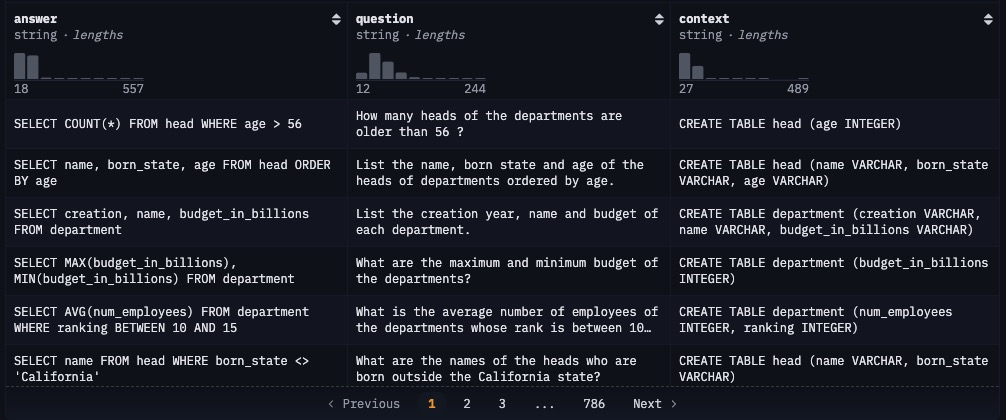

一般来说我们按照样例数据集，提供这三个信息也就可以了，但是经过我们今天的讲解，我们知道prompt中除了给出数据表的结构，还可以增加相关的查询示例。
如果在推理阶段用到了示例，但在训练阶段没用，这就造成了训推模式的不一致，虽然我们不能断定一定会影响结果，但我们还是尽量保证训推的Prompt组成是一致的。
在上面我们已经给出了如何收集用户真实的查询示例，并且特别关注哪些是系统没办法给出正确结果的。对于后者我们可以通过人工补充正确答案，并且补充到训练样本中插入到Prompt中。

最终我们可以使用以下模板来组合使用：

```python
TEMPLATE = """你是一位专业的数据专员，非常擅长根据查询需求写出对应的SQL命令。
请根据提供给你的数据库表结构和相关的查询示例，对查询需求写出可执行的SQL命令。

- 数据表
{table_info}

- 示例
{examples}

查询需求: {query}
SQL:
"""
```

其中example代表和当前query比较相关的几个示例，我们可以设计一些挑选规则，比如
- 查的是相同的表
- 使用的子函数(sum、avg)相同
- 查询表述语义相近

### 精细化库表分类 & COT

在实际的业务场景中，有时候我们会遇到多库检索的场景，这时候我们就需要先判断查询需求是针对哪个数据库的，最简单的实现方案就是利用大模型进行分类：

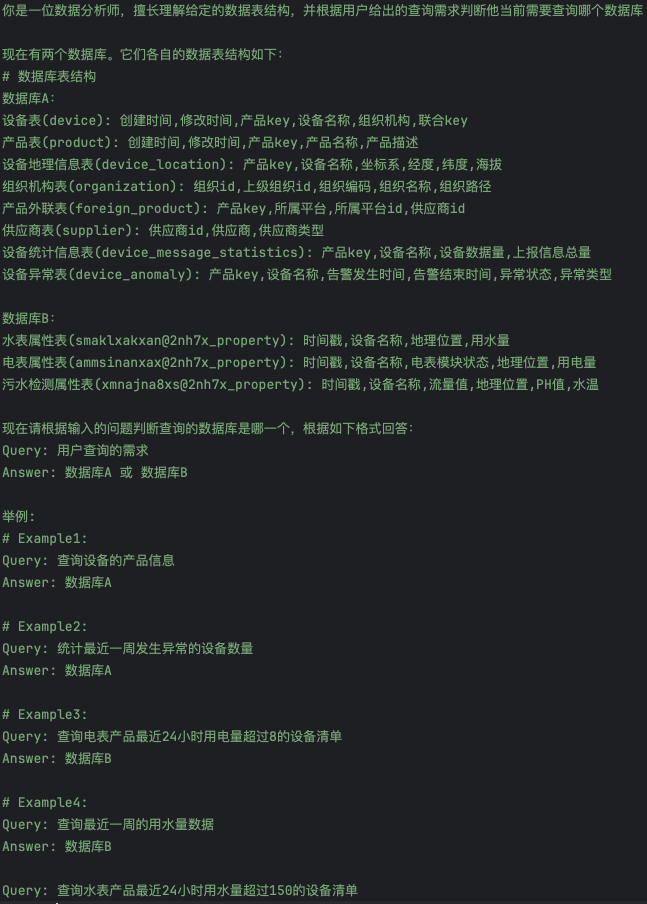

在使用langchain的实现方案中，挑选数据表的环节是在生成SQL答案前先进行的，这种策略适合数据库中数据表数量非常庞大的场景，这样方便我们单独优化数据表的挑选准确率。如果数据表数量不是特别大，我们也可以尝试将数据表、甚至于数据表的字段挑选工作也放在模板中，通过COT让模型在生成答案时先思考需要使用哪张表。

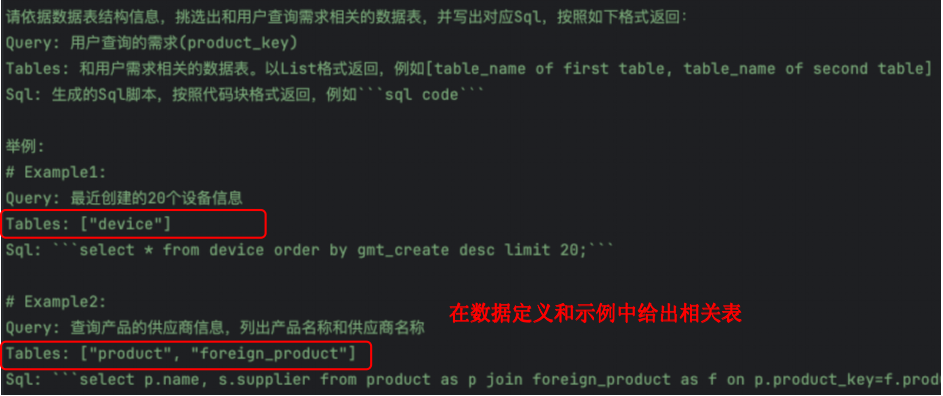

### 精简提示词长度 -> 提升推理压力

影响推理速度的主要因素：
- 模型参数规模：参数量越少、精度越低、推理速度越快
- GPU型号：A100 ≈ A800 > V100 > A10 > T4 
- 架构实现：优化Attention等关键模块在显存中的计算方法、实现参数解耦、IO感知的显存计算能大大提升推理速度
- 词表大小：词表越大，解码时的步数越少，生成答案所需的时间越少
- `输入长度：输入句子越长，模型的计算量越大，推理所需时间越长`

问：怎么让Prompt变短一点呢？

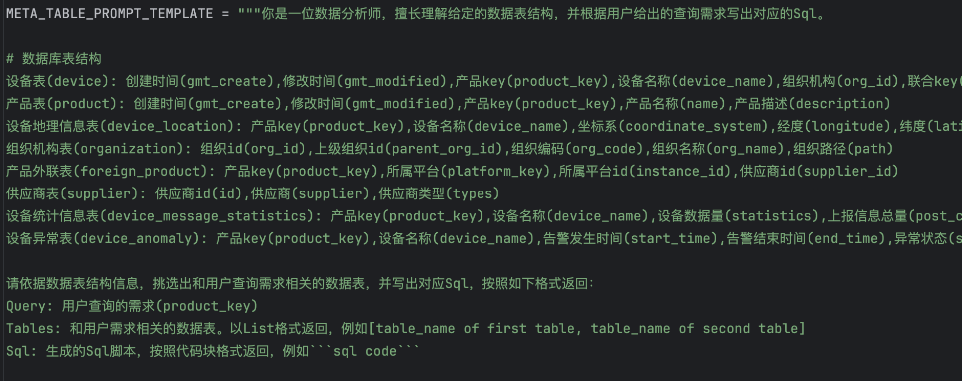

`参考P-Tuning V2原理，将Prompt中固定的长语段替换成固定的特殊标签，模型做每次推理前，只要看到这个标签就明白它等同于一段长文本所表达的语义`。

Tshort_instruction:

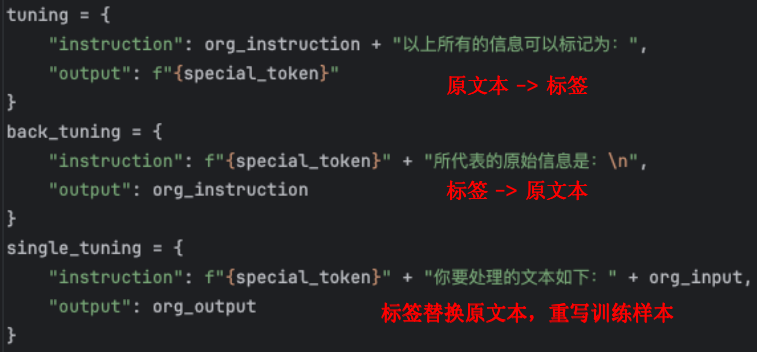


### Self-InStruction扩充问题集

当我们可用于训练的样本太少的时候，我们就要想办法扩充数据集。最靠谱的方法就是靠人去想用户会问什么问题，但这个效率太低了，我们可以借助Self-struction的方法自动生成问题：将数据表结构扫到prompt中，在准备一些样例问题，让大模型观察这些数据表结构，扮演真实用户提一些查询问题。去除质量低下的，输入给大模型先走一遍text2sql，把效果差的样本摘出来，让人工补充正确答案。

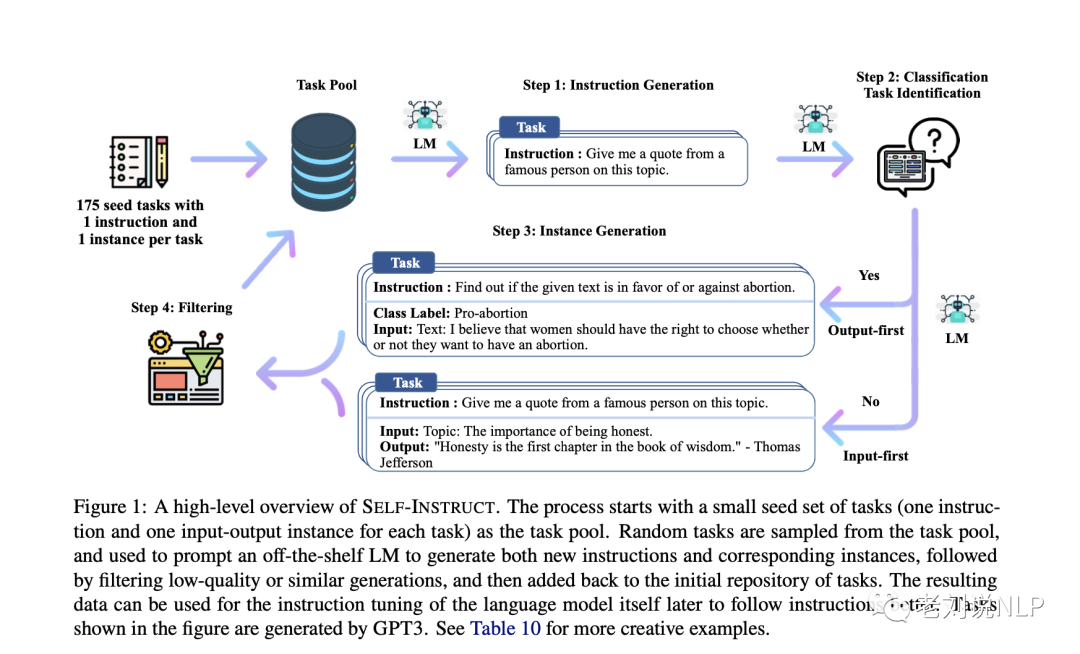

### 指令微调

和LLaMA-Factory一样，Swift也支持自定义数据集，我们只要将上述数据改写成QA的格式，就能按照框架的微调流程训练我们的大模型。个人建议用sharegpt格式，支持多轮对话，因为在ChatBI场景下多轮对话是非常常见的。

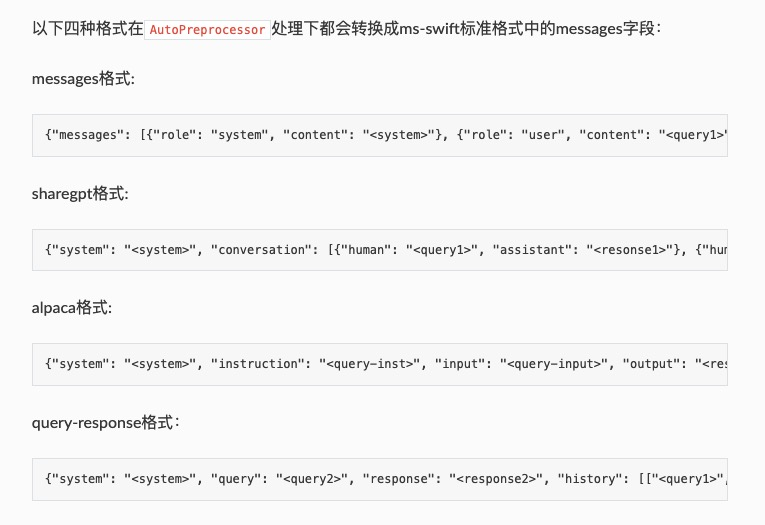

## 难点与挑战

- 当前AI模型输出SQL的准确性还远无法达到人类工程师的输出精度。
- 自然语言表达本身的歧义性，而SQL是一种精确编程语言。因此在实际应用中，可能会出现无法理解，或者错误理解的情况。比如，“谁是这个月最厉害的销售”，那么AI是理解成订单数量最多，还是订单金额最大？
- 尽管可以通过Prompt输入数据结构信息帮助AI模型来理解，但有时候AI可能会由于缺乏外部行业知识导致错误。比如，“分析去年的整体客户流失率？”，如果AI缺乏对“客户流失率”的理解，自然就会出错或者编造。

Text2SQL的方案在企业应用中还会面临两个严重的挑战：

- 可能会出现正常运行的“假象”
    - 即正常完成了任务，但实际结果是错误的。由于NL2SQL是直接输出用于数据库访问的语句，理论上只要不存在基本的语法错误，就可以执行成功，即使转换的SQL在语义上是错误的！
    - NL2SQL输出语义准确性衡量的复杂性本质上来自于这样一个事实：判断AI输出的一段代码是否正确，要比判断一个选择题答案是否正确，或者一段字符串的相似度要复杂的多。
    - 评估NL2SQL模型输出正确性的复杂所在：你既不能用输出SQL的执行结果来判断，也不能简单的把输出SQL与标准答案对比来判断。

- 企业应用的特点会加大错误输出的概率